In [34]:
import numpy as np
import itertools
import time
import reservoirpy
from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge, ScikitLearnNode
from reservoirpy.observables import spectral_radius
from sklearn.linear_model import Lasso

reservoirpy.set_seed(42)

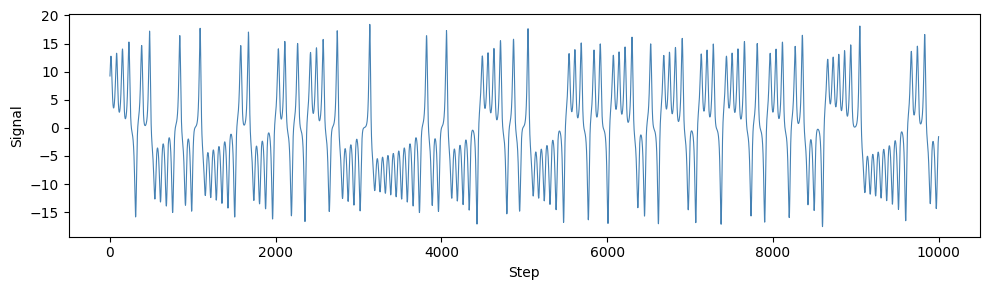

In [35]:
# LOAD DATA
# data should be a 1D numpy array
dataset = np.loadtxt('../data/chaotic_data/lorenz_system.csv', delimiter=',')
dataset = dataset[: ,0]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

In [ ]:
# PREPARE DATA
data = dataset.reshape(-1, 1)
# X[t] = data[t], Y[t] = data[t+1]
X = data[:-1]
Y = data[1:]

train_len = 3000          # train on [0 : train_len]
train_warmup = 100        # discard first transient states during fit

# Test window can be right after training or far away
test_start = 3000
test_len = 2000

warmup_len = 500          # synchronization using true data inside chosen test window

# Training data
X_train = X[:train_len]
Y_train = Y[:train_len]

# Chosen test window
X_test = X[test_start:test_start + test_len]
Y_test = Y[test_start:test_start + test_len]

# Prediction portion is after local test warmup
pred_len = test_len - warmup_len
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]

regression_model = "lasso"  # "ridge" or "lasso"

# DEFINE PARAMETER GRID
param_grid = {
    'units':         [500, 800, 1000, 1500],
    'sr':            [0.8, 0.95, 0.99, 1.2, 1.3, 1.4, 1.5],
    'lr':            [0.1, 0.3, 0.5, 1.0],
    'input_scaling': [0.05, 0.1, 0.5, 1.0, 1.1],
    'regression':    [1e-6, 1e-4, 1e-3, 1e-2, 1e-1],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))
print(f"Total combinations to evaluate: {len(combos)}")

# EVALUATION FUNCTION
def evaluate_esn(units, sr, lr, input_scaling, regression, seed=42):
    """
    Build, train, reset, synchronize on chosen test window,
    then run closed-loop prediction and return NRMSE.
    """
    try:
        reservoir = Reservoir(
            units=int(units),
            lr=lr,
            W=uniform(low=-0.5, high=0.5, connectivity=1.0, sr=sr),
            Win=uniform(low=-0.5 * input_scaling, high=0.5 * input_scaling, connectivity=1.0),
            bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
            activation="tanh",
            seed=seed
        )

        if regression_model == "ridge":
            readout = Ridge(ridge=regression)
        else: 
            readout = ScikitLearnNode(model=Lasso, alpha=regression, max_iter=10000)
        esn = reservoir >> readout

        # Train on first segment
        esn.fit(X_train, Y_train, warmup=train_warmup)

        # Reset before any test window
        esn.reset()

        # Synchronize on first part of chosen test window
        if warmup_len > 0:
            esn.run(X_test[:warmup_len])

        # Closed-loop prediction on the rest
        Y_pred = []
        current_input = X_test[warmup_len:warmup_len + 1]

        for _ in range(pred_len):
            pred = esn.run(current_input)
            pred = np.asarray(pred).reshape(1, -1)
            Y_pred.append(pred[0, 0])
            current_input = pred

        Y_pred = np.array(Y_pred)

        # Divergence check
        if np.any(np.isnan(Y_pred)) or np.max(np.abs(Y_pred)) > 1e6:
            return np.inf

        rmse = np.sqrt(np.mean((Y_true - Y_pred) ** 2))
        nrmse = rmse / np.std(Y_true)
        return nrmse

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf

# RUN GRID SEARCH
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_esn(**params)
    results.append({**params, 'nrmse': nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(f"[{i+1}/{len(combos)}]  elapsed: {elapsed:.0f}s  "
              f"current best NRMSE: {best_nrmse:.6f}")

total_time = time.time() - t_start

# RESULTS
print("\n" + "=" * 60)
print("GRID SEARCH COMPLETE")
print(f"Train interval : [0 : {train_len}]")
print(f"Test interval  : [{test_start} : {test_start + test_len}]")
print(f"Warmup length  : {warmup_len}")
print(f"Pred. length   : {pred_len}")
print(f"Total time     : {total_time:.1f}s ({total_time/len(combos):.2f}s per trial)")
print(f"Best NRMSE     : {best_nrmse:.6f}")
print(f"Regression model: {regression_model}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:20s} = {v}")
print("=" * 60)

# TOP 10 CONFIGURATIONS
results_sorted = sorted(results, key=lambda r: r['nrmse'])

print("\nTop 10 configurations:")
print(f"{'Rank':>4}  {'units':>5}  {'sr':>5}  {'lr':>4}  {'in_sc':>6}  {'regression':>8}  {'NRMSE':>10}")
print("-" * 62)

for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['sr']:5.2f}  "
        f"{r['lr']:4.1f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['regression']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )


# VISUALIZE BEST ESN
# REBUILD BEST ESN
best_reservoir = Reservoir(
    units=int(best_params['units']),
    lr=best_params['lr'],
    W=uniform(low=-0.5, high=0.5, connectivity=1.0, sr=best_params['sr']),
    Win=uniform(
        low=-0.5 * best_params['input_scaling'],
        high=0.5 * best_params['input_scaling'],
        connectivity=1.0
    ),
    bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
    activation="tanh",
    seed=42
)

if regression_model == "ridge":
    best_readout = Ridge(ridge=best_params['regression'])
else: 
    best_readout = ScikitLearnNode(model=Lasso, alpha=best_params['regression'], max_iter=10000)
best_esn = best_reservoir >> best_readout

# TRAIN
best_esn.fit(X_train, Y_train, warmup=100)

# TEST (RESET + LOCAL WARMUP + CLOSED LOOP)
best_esn.reset()

if warmup_len > 0:
    best_esn.run(X_test[:warmup_len])

pred_len = test_len - warmup_len

Y_pred_best = []
current_input = X_test[warmup_len:warmup_len + 1]

for _ in range(pred_len):
    pred = best_esn.run(current_input)
    pred = np.asarray(pred).reshape(1, -1)
    Y_pred_best.append(pred[0, 0])
    current_input = pred

Y_pred_best = np.array(Y_pred_best)

# Ground truth aligned
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]

mse = np.mean((Y_true - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true)


fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test[:, 0], c='green', label="Ground truth", linewidth=1.2)
ax.axvline(warmup_len, linestyle="--", c='k',linewidth=1.0, label="Warmup end")
ax.plot(np.arange(warmup_len, warmup_len + pred_len), Y_pred_best,
        linestyle="--", c='red', linewidth=1.2, label="ESN closed-loop prediction")
ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"units={int(best_params['units'])}, sr={best_params['sr']}, "
    f"lr={best_params['lr']}, in_sc={best_params['input_scaling']}, "
    f"reg={best_params['regression']:.0e}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()

Total combinations to evaluate: 2800


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.193e+02, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(
/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.851e+01, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(
/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to inc

[20/2800]  elapsed: 31s  current best NRMSE: 1.029642


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.234e+01, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(
/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.619e+02, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(


[40/2800]  elapsed: 55s  current best NRMSE: 1.029642


...

[1540/2800]  elapsed: 3400s  current best NRMSE: 0.865519
[1560/2800]  elapsed: 3474s  current best NRMSE: 0.865519
[1580/2800]  elapsed: 3555s  current best NRMSE: 0.865519
[1600/2800]  elapsed: 3656s  current best NRMSE: 0.865519


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.403e+01, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(
/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.433e+02, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(
/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to inc

[1620/2800]  elapsed: 3732s  current best NRMSE: 0.865519


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.201e+01, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(
/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.890e+01, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(
/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to inc

[1640/2800]  elapsed: 3791s  current best NRMSE: 0.865519
[1660/2800]  elapsed: 3840s  current best NRMSE: 0.865519
